In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import scipy

In [11]:
df=pd.read_csv('Auto Sales data.csv')
df_taqui=df.copy()
df_taqui

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,24/02/2018,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,07/05/2018,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,01/07/2018,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,25/08/2018,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.66,1,3479.76,28/10/2018,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,6505556809,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2742,10350,20,112.22,15,2244.40,02/12/2019,2924,Shipped,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,28034,Spain,Freyre,Diego,Small
2743,10373,29,137.19,1,3978.51,31/01/2020,2865,Shipped,Ships,54,S72_3212,"Oulu Toy Supplies, Inc.",981-443655,Torikatu 38,Oulu,90110,Finland,Koskitalo,Pirkko,Medium
2744,10386,43,125.99,4,5417.57,01/03/2020,2836,Resolved,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",Madrid,28034,Spain,Freyre,Diego,Medium
2745,10397,34,62.24,1,2116.16,28/03/2020,2810,Shipped,Ships,54,S72_3212,Alpha Cognac,61.77.6555,1 rue Alsace-Lorraine,Toulouse,31000,France,Roulet,Annette,Small


In [13]:
df_taqui['ORDERDATE'] = pd.to_datetime(df_taqui['ORDERDATE'])


df_taqui['Year'] = df_taqui['ORDERDATE'].dt.year
df_taqui['Month'] = df_taqui['ORDERDATE'].dt.month


C:\Users\taqui\AppData\Local\Temp\ipykernel_24476\2091891716.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_taqui['ORDERDATE'] = pd.to_datetime(df_taqui['ORDERDATE'])


**SALES PERFORMANCE ANALYSIS**


In [10]:
print("Total Sales Revenue:", df_taqui['SALES'].sum())


Total Sales Revenue: 9760221.71


**YEAR WISE SALES**


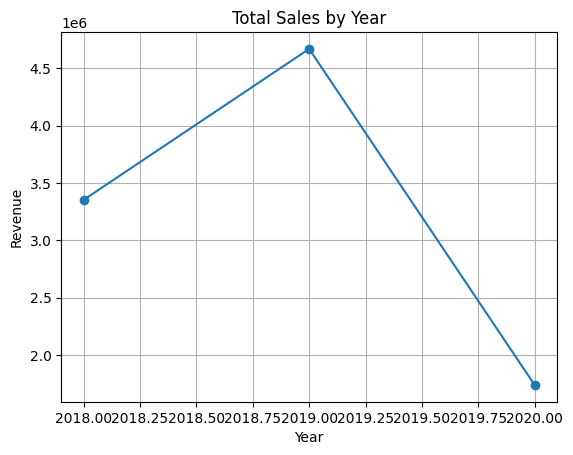

In [14]:
df_taqui.groupby('Year')['SALES'].sum().plot(marker='o', title='Total Sales by Year')
plt.ylabel('Revenue')
plt.grid(True)


**The year-wise sales analysis shows clear variation in revenue performance over time:**

-2019 had the highest total sales, with ₹4.67 million, indicating strong market activity and product performance.

-2018 followed, with sales of ₹3.35 million, showing a stable foundation before the peak.

-2020 showed a steep decline, dropping to just ₹1.73 million, likely due to external disruptions like the COVID-19 pandemic or internal business constraints.

**MONTH WISE SALES**


Text(0.5, 0, 'Month')

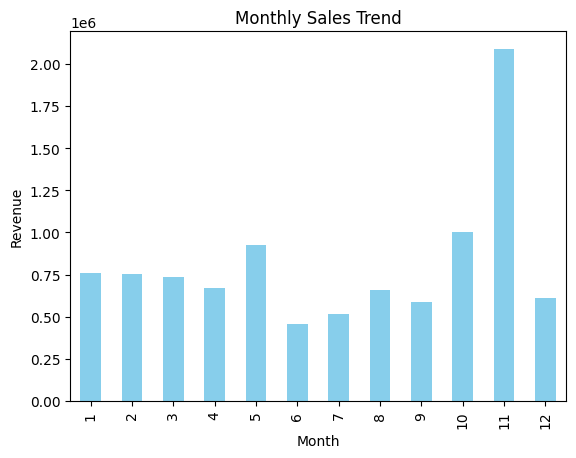

In [15]:
df_taqui.groupby('Month')['SALES'].sum().plot(kind='bar', color='skyblue', title='Monthly Sales Trend')
plt.ylabel('Revenue')
plt.xlabel('Month')

-The analysis shows that November had the highest sales, indicating a likely seasonal demand spike, possibly due to year-end promotions, holiday shopping, or festive season campaigns.

-In contrast, June recorded the lowest sales, suggesting a mid-year sales slump, which could be a typical off-season period.

-Other months had relatively consistent sales, reflecting stable demand across the rest of the year.
This seasonal trend highlights opportunities for targeted marketing and inventory planning to capitalize on high-performing months like November.

**SALES BY COUNTRY**

Text(0.5, 1.0, 'Top 5 Countries by Revenue')

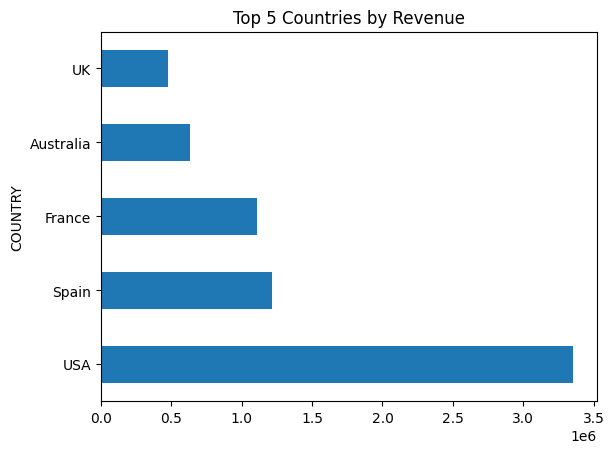

In [16]:
df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False).head(5).plot(kind='barh')
plt.title('Top 5 Countries by Revenue')


-THIS SHOWS THAT USA HAD THE HIGHEST SALES 

-WHILE UK HAD THE LOWEST 

**VEHICLE CATEGORY/MODEL INSIGHTS**

**Top Product Lines **

Text(0.5, 0, 'Units Sold')

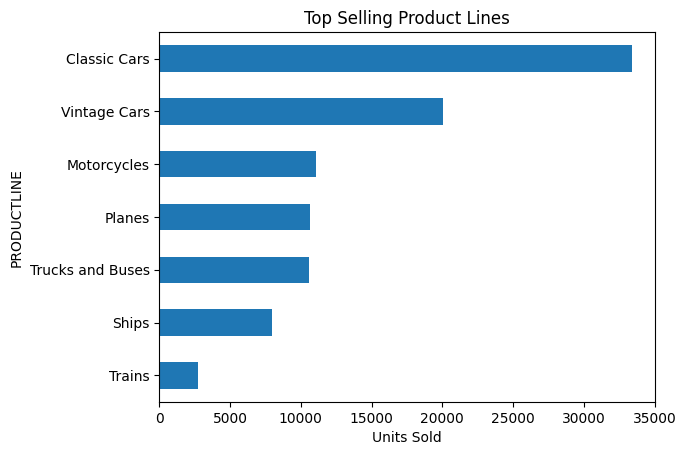

In [19]:
df_taqui.groupby('PRODUCTLINE')['QUANTITYORDERED'].sum().sort_values().plot(kind='barh')
plt.title('Top Selling Product Lines')
plt.xlabel('Units Sold')


THIS DATA SHOWS THAT CARS ARE SOLD THE HIGHEST , WHILE THE OTHERS VEHICLES ARE SOLD RELATIVELY LOW 

WITH TRAINS HAVING THE LOWEST VALUE 


**Revenue by Product Line**

Text(0.5, 0, 'Revenue')

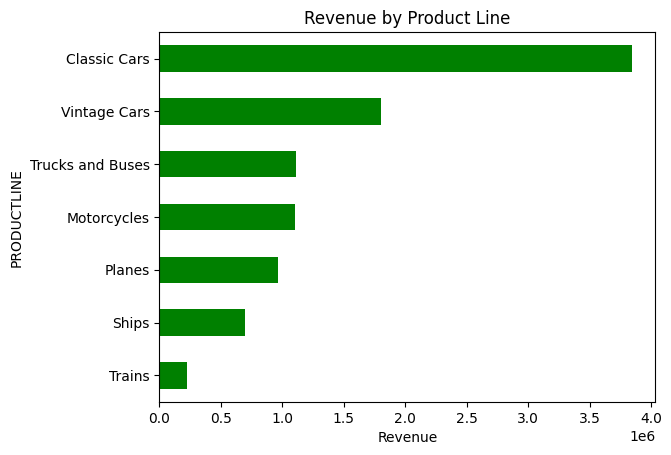

In [20]:
df_taqui.groupby('PRODUCTLINE')['SALES'].sum().sort_values().plot(kind='barh', color='green')
plt.title('Revenue by Product Line')
plt.xlabel('Revenue')


THIS DATA SHOWS SIMILAR RESULTS WITH THAT OF THE SOLD VEHICLES, WHICH GIVES US A  HINT THAT MORE THE VEHICLES

GET SOLD , MORE IS THE REVENUE

**PRICE VS QUANTITY**

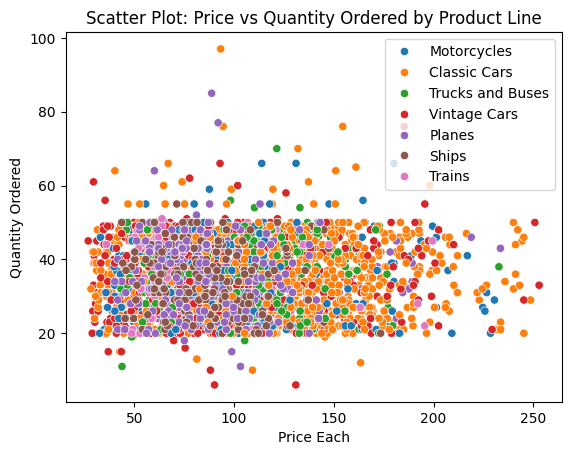

In [21]:

sns.scatterplot(data=df_taqui, x='PRICEEACH', y='QUANTITYORDERED', hue='PRODUCTLINE', edgecolor='w')
plt.title('Scatter Plot: Price vs Quantity Ordered by Product Line')
plt.xlabel('Price Each')
plt.ylabel('Quantity Ordered')
plt.legend()

plt.show()


-The scatter plot shows the as the price increases the sales also decrease

-Classic Cars and Motorcycles are the most "mass-market" product lines.

-Luxury categories like Planes follow a low-volume, high-margin strategy.



** A BETTER VIEW**

C:\Users\taqui\AppData\Local\Temp\ipykernel_24476\4290747705.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_taqui['SALES'], bins=30, color='red')


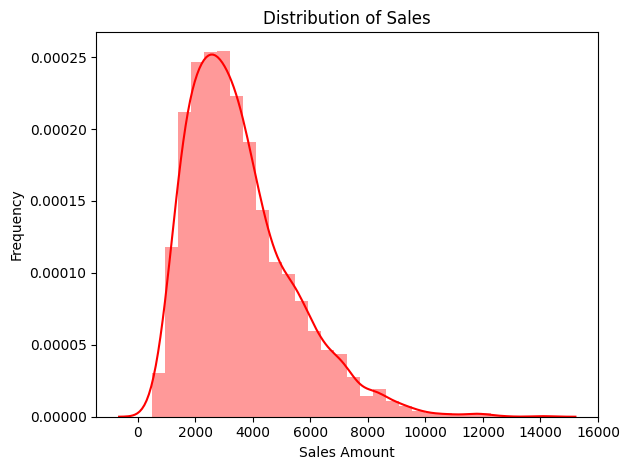

In [26]:

sns.distplot(df_taqui['SALES'], bins=30, color='red')
plt.title('Distribution of Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
